<a href="https://colab.research.google.com/github/ctrlalt-buhle/ML-Algorithms-Dementia-Project/blob/main/Dementia_Detection_MLipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dementia Detection - Machine Learning Project
###Module ITMLA2-44 | Machine Learning Algorithms | Eduvos


---
##Project Goal
Build a machine lerning model to predict whether a patient has Dementia based on clinical, lifestyle, and demographic data.

##Dataset
- **File:** dementia.csv
- **Patients:** 2,149
- **Features:** 35 columns
- **Target:** Diagnosis (0 = No Dementia, 1 = Dementia)

##Methdology

1. Data Preprocessing
2. Feature Selection (SelectKBest & RFE)
3. Classification Models (Logistic Regression & Decision Tree)
4. Model Evaluation & Comaprison






In [1]:
## Step 1: Import Libraries

In [2]:
# ── DATA MANIPULATION ───────────────────────────────────────
import pandas as pd        # Working with tables/dataframes
import numpy as np         # Mathematical operations on arrays

# ── VISUALISATION ───────────────────────────────────────────
import matplotlib.pyplot as plt   # Creating plots and charts
import seaborn as sns             # Beautiful statistical visuals

# ── PREPROCESSING ───────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder  → converts text categories to numbers (e.g Yes/No → 1/0)
# StandardScaler → rescales numbers to have mean=0, std=1

# ── FEATURE SELECTION ───────────────────────────────────────
from sklearn.feature_selection import SelectKBest, chi2, RFE
# SelectKBest → picks top K features using a statistical test
# chi2        → the statistical test we'll use (works for classification)
# RFE         → Recursive Feature Elimination (wrapper method)

# ── MACHINE LEARNING MODELS ─────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ── MODEL EVALUATION ────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# ── SETTINGS ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # Keep output clean
sns.set_style('whitegrid')          # Clean plot background

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
## Step 2: Load & Mount Dataset

In [4]:
# Mount Google Drive so Colab can access your files
from google.colab import drive
drive.mount('/content/drive')

# ── PATH TO YOUR DATA ───────────────────────────────────────
# Update this if your folder name is different
DATA_PATH = '/content/drive/MyDrive/'

# ── LOAD THE DATASET ────────────────────────────────────────
# index_col=0 tells pandas the first column is the row index,
# not an actual feature — prevents an unnamed column appearing
df = pd.read_csv(DATA_PATH + 'dementia.csv', index_col=0)

# ── QUICK OVERVIEW ──────────────────────────────────────────
print(f"Dataset loaded!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"\n Target Distribution:")
print(df['Diagnosis'].value_counts())
print(f"\n First 3 rows:")
df.head(3)

Mounted at /content/drive
Dataset loaded!
   Rows    : 2149
   Columns : 35

 Target Distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

 First 3 rows:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,Male,Caucasian,Bachelors,22.927749,No,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,No,0,XXXConfid
1,4752,89,Male,Caucasian,NaN,26.827681,No,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,Yes,0,XXXConfid
2,4753,73,Male,Other,High School,17.795882,No,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,No,0,XXXConfid


In [5]:
import os

# List contents of the DATA_PATH directory
try:
    print(f"Listing contents of: {DATA_PATH}")
    for root, dirs, files in os.walk(DATA_PATH):
        for name in files:
            print(os.path.join(root, name))
        for name in dirs:
            print(os.path.join(root, name))
except Exception as e:
    print(f"Error listing directory: {e}")


Listing contents of: /content/drive/MyDrive/
/content/drive/MyDrive/Resume (3).gdoc
/content/drive/MyDrive/Resume (2).gdoc
/content/drive/MyDrive/Resume (1).gdoc
/content/drive/MyDrive/retail_sales_dataset.csv
/content/drive/MyDrive/Letter.gdoc
/content/drive/MyDrive/SUCCESS CONNECT - Google Chrome 2026-02-23 20-17-28.mp4
/content/drive/MyDrive/Question 1.5.drawio
/content/drive/MyDrive/Resume.gdoc
/content/drive/MyDrive/Business-Adventures_-Twelve-John-Brooks-1 (13)_copy.pdf
/content/drive/MyDrive/Bill_Gates_John_Brooks_Business_Adventures_Review_Xerox_Free_Chapter_copy.pdf
/content/drive/MyDrive/Sapiens A Brief History of Humankind_copy.pdf
/content/drive/MyDrive/TheGivingTreePoem_copy.pdf
/content/drive/MyDrive/GGIM SERVICE.ewsx
/content/drive/MyDrive/BN Malinga_CV.pdf
/content/drive/MyDrive/dementia.csv
/content/drive/MyDrive/uber_eats.csv
/content/drive/MyDrive/wine_clustering.csv
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Colab Notebooks/ZAR-Alpha-Metrics.ipynb

In [6]:
# ── CHECK DATA TYPES AND MISSING VALUES ─────────────────────
# Gives us a birds-eye view of the dataset

print("=" * 55)
print("Dataset Info")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("Missing Values Per Column")
print("=" * 55)
# isnull() marks every missing cell as True
# .sum() counts the Trues per column
missing = df.isnull().sum()

# Only show columns that actually have missing values
print(missing[missing > 0])
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

Dataset Info
<class 'pandas.core.frame.DataFrame'>
Index: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   object 
 3   Ethnicity                  2149 non-null   object 
 4   EducationLevel             1703 non-null   object 
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   object 
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryDementia      2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null

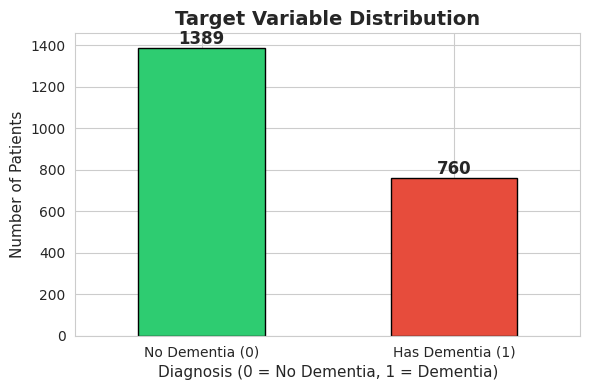

Plot saved as target_distribution.png


In [7]:
# ── CHECK TARGET DISTRIBUTION VISUALLY ──────────────────────
# A bar chart is clearer than numbers alone
# Helps us see the imbalance

fig, ax = plt.subplots(figsize=(6, 4))

# Count each class and plot
df['Diagnosis'].value_counts().plot(
    kind='bar',
    color=['#2ecc71', '#e74c3c'],  # Green = No, Red = Yes
    edgecolor='black',
    ax=ax
)

# Labels and formatting
ax.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Diagnosis (0 = No Dementia, 1 = Dementia)', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.set_xticklabels(['No Dementia (0)', 'Has Dementia (1)'], rotation=0)

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as target_distribution.png")

In [8]:
# ── STATISTICAL SUMMARY ─────────────────────────────────────
# .describe() shows us for every numeric column:
# count, mean, std, min, 25%, 50%, 75%, max
#
# This helps us spot:
# → Outliers (e.g. a BMI of 999 would stand out)
# → Expected ranges (e.g. Age should be 60-90)
# → Whether scaling is needed (columns on very different scales)

print("=" * 55)
print("Statistical Summary of Numeric Features")
print("=" * 55)
df.describe().round(2)

Statistical Summary of Numeric Features


,PatientID,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryDementia,CardiovascularDisease,Diabetes,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Diagnosis
count,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,...,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00
mean,5825.00,74.91,27.66,10.04,4.92,4.99,7.05,0.25,0.14,0.15,...,14.76,5.08,0.21,0.16,4.98,0.21,0.16,0.15,0.16,0.35
std,620.51,8.99,7.22,5.76,2.86,2.91,1.76,0.43,0.35,0.36,...,8.61,2.89,0.41,0.36,2.95,0.40,0.37,0.36,0.37,0.48
min,4751.00,60.00,15.01,0.00,0.00,0.01,4.00,0.00,0.00,0.00,...,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,5288.00,67.00,21.61,5.14,2.57,2.46,5.48,0.00,0.00,0.00,...,7.17,2.57,0.00,0.00,2.34,0.00,0.00,0.00,0.00,0.00
50%,5825.00,75.00,27.82,9.93,4.77,5.08,7.12,0.00,0.00,0.00,...,14.44,5.09,0.00,0.00,5.04,0.00,0.00,0.00,0.00,0.00
75%,6362.00,83.00,33.87,15.16,7.43,7.56,8.56,1.00,0.00,0.00,...,22.16,7.55,0.00,0.00,7.58,0.00,0.00,0.00,0.00,1.00
max,6899.00,90.00,39.99,19.99,9.99,10.00,10.00,1.00,1.00,1.00,...,29.99,10.00,1.00,1.00,10.00,1.00,1.00,1.00,1.00,1.00


## Step 4: Data Preprocessing

Preprocessing transforms raw data into a clean, structured
format that machine learning models can learn from effectively.

Steps:
1. Drop irrelevant columns
2. Handle missing values
3. Encode categorical variables
4. Separate features and target
5. Standardise continuous features

In [9]:
# ── STEP 1: DROP IRRELEVANT COLUMNS ─────────────────────────
# PatientID    → unique number per patient, no predictive value
#                A model would try finding patterns in arbitrary
#                ID numbers which leads to noise, not relevance
#
# DoctorInCharge → every single value is 'XXXConfid' (confidential)
#                  one unique value = zero information for the model

cols_to_drop = ['PatientID', 'DoctorInCharge']
df.drop(columns=cols_to_drop, inplace=True)
# inplace=True means we modify the existing df
# instead of creating a new one

print(f"Dropped: {cols_to_drop}")
print(f"   Remaining columns: {df.shape[1]}")

Dropped: ['PatientID', 'DoctorInCharge']
   Remaining columns: 33


In [10]:
# ── STEP 1: DROP IRRELEVANT COLUMNS ─────────────────────────
# PatientID is already excluded because we used index_col=0
# when loading the CSV — Pandas set it as the row index
# automatically, removing it from our feature columns.
#
# DoctorInCharge → every value is 'XXXConfid' (confidential)
# one unique value = zero information for the model

# Only drop columns that actually exist in df
cols_to_drop = [col for col in ['DoctorInCharge']
                if col in df.columns]

df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped: {cols_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Dropped: []
Remaining columns: 33


In [11]:
print("Variables currently defined in the kernel:")
%whos

Variables currently defined in the kernel:
Variable                 Type         Data/Info
-----------------------------------------------
ConfusionMatrixDisplay   type         <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DATA_PATH                str          /content/drive/MyDrive/
DecisionTreeClassifier   ABCMeta      <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
LabelEncoder             type         <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression       type         <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RFE                      ABCMeta      <class 'sklearn.feature_selection._rfe.RFE'>
SelectKBest              ABCMeta      <class 'sklearn.feature_s<...>e_selection.SelectKBest'>
StandardScaler           type         <class 'sklearn.preproces<...>ng._data.StandardScaler'>
accuracy_score           function     <function accuracy_score at 0x7d4b7fcacfe0>
ax                       Axes         Axes(0.134005,0.148194;0.840995x

In [12]:
# See exactly what columns currently exist in df
print(df.columns.tolist())

['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryDementia', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']


In [13]:
# ── STEP 2: HANDLE MISSING VALUES ───────────────────────────
# Only 'EducationLevel' has missing values (446 out of 2,149)
# That is 20.8% of our data
#
# Option A — Drop rows:
#   Simple but we LOSE 446 patient records
#   In healthcare, every patient record is valuable
#   We could accidentally remove important dementia patterns
#
# Option B — Impute with MODE (perfect choice):
#   Mode = the most frequently occurring category
#   We fill the gaps with the most common education level
#   We keep ALL 2,149 patients intact

print("=" * 50)
print("Before imputation:")
print(f"Missing in EducationLevel: {df['EducationLevel'].isnull().sum()}")
print(f"Mode (most common value) : '{df['EducationLevel'].mode()[0]}'")

# Fill missing values with the mode
df['EducationLevel'] = df['EducationLevel'].fillna(
    df['EducationLevel'].mode()[0]
)

print("\nAfter imputation:")
print(f"Missing in EducationLevel: {df['EducationLevel'].isnull().sum()}")
print(f"Total missing values left: {df.isnull().sum().sum()}")
print("All missing values handled!")

Before imputation:
Missing in EducationLevel: 446
Mode (most common value) : 'High School'

After imputation:
Missing in EducationLevel: 0
Total missing values left: 0
All missing values handled!


In [14]:
# ── STEP 3: ENCODE CATEGORICAL VARIABLES ────────────────────
# Machine learning models only understand NUMBERS, not text.
# Convert text categories into numeric form.
#
# Use TWO different encoding strategies:
#
# STRATEGY A — Label Encoding (for binary columns)
#   Binary = only 2 unique values (e.g. Yes/No, Male/Female)
#   We simply map them to 0 and 1
#   Example: Gender → Female=0, Male=1
#
# STRATEGY B — One-Hot Encoding (for multi-class columns)
#   Multi-class = 3 or more categories (e.g. Ethnicity)
#   We create a NEW column for each category
#   Each column contains 0 or 1
#
#   WHY NOT just use Label Encoding for everything?
#   Because Label Encoding implies ORDER

print("=" * 50)
print("STRATEGY A: Label Encoding (Binary Columns)")
print("=" * 50)

# Initialise the LabelEncoder
le = LabelEncoder()

# These columns each have exactly 2 unique values
binary_cols = ['Gender', 'Smoking', 'Forgetfulness']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    # fit_transform learns the mapping AND applies it
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  '{col}': {mapping}")

print("\n" + "=" * 50)
print("STRATEGY B: One-Hot Encoding (Multi-Class Columns)")
print("=" * 50)

# These columns have 3+ categories with no meaningful order
ohe_cols = ['Ethnicity', 'EducationLevel']

df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
# drop_first=True removes one dummy column per feature
# This avoids the "dummy variable trap" — multicollinearity
# where one column can be perfectly predicted from the others

print(f"  One-Hot Encoded: {ohe_cols}")
print(f"  Dataset shape after encoding: {df.shape}")
print("\n All categorical variables encoded!")

STRATEGY A: Label Encoding (Binary Columns)
  'Gender': {'Female': np.int64(0), 'Male': np.int64(1)}
  'Smoking': {'No': np.int64(0), 'Yes': np.int64(1)}
  'Forgetfulness': {'No': np.int64(0), 'Yes': np.int64(1)}

STRATEGY B: One-Hot Encoding (Multi-Class Columns)
  One-Hot Encoded: ['Ethnicity', 'EducationLevel']
  Dataset shape after encoding: (2149, 36)

 All categorical variables encoded!


In [15]:
# ── STEP 4: SEPARATE FEATURES AND TARGET ────────────────────
# Before scaling, we split our dataframe into:
#
# X → Feature matrix (everything the model LEARNS FROM)
#     All columns except Diagnosis
#
# y → Target vector (what the model PREDICTS)
#     Just the Diagnosis column (0 or 1)

X = df.drop(columns=['Diagnosis'])  # Features
y = df['Diagnosis']                 # Target

print(f" Features (X): {X.shape[1]} columns × {X.shape[0]} rows")
print(f" Target   (y): {y.shape[0]} values")
print(f"\nTarget breakdown:")
print(f"   No Dementia (0): {(y==0).sum()}")
print(f"   Has Dementia(1): {(y==1).sum()}")

 Features (X): 35 columns × 2149 rows
 Target   (y): 2149 values

Target breakdown:
   No Dementia (0): 1389
   Has Dementia(1): 760


In [16]:
# ── STEP 5: FEATURE STANDARDISATION ─────────────────────────
# StandardScaler rescales continuous features to have:
#   Mean = 0 and Standard Deviation = 1
#
# BEFORE scaling example:
#   Age             → ranges 60  to 90
#   CholesterolTotal → ranges 150 to 300
#
# AFTER scaling:
#   Both features → roughly -3 to +3
#
# WHY THIS MATTERS:
# Logistic Regression uses gradient descent internally
# Gradient descent is sensitive to scale — it takes
# much longer to converge (find the best solution)
# when features are on very different scales
#
# NOTE: We only scale CONTINUOUS numeric features
# Binary columns (0/1) and one-hot encoded columns
# are already on the same scale — scaling them again
# would distort their meaning

continuous_cols = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
    'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
    'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL'
]

# Initialise the scaler
scaler = StandardScaler()

# fit_transform on X:
# fit    → calculates the mean and std of each column
# transform → applies the scaling formula: (value - mean) / std
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

# Verify it worked — mean should be ~0, std should be ~1
print(" Standardisation complete!")
print(f"\nVerification on 'Age' after scaling:")
print(f"   Mean : {X['Age'].mean():.6f}  (should be ~0)")
print(f"   Std  : {X['Age'].std():.6f}  (should be ~1)")
print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Any remaining nulls: {X.isnull().sum().sum()}")

 Standardisation complete!

Verification on 'Age' after scaling:
   Mean : 0.000000  (should be ~0)
   Std  : 1.000233  (should be ~1)

Final feature matrix shape: (2149, 35)
Any remaining nulls: 0


## Step 5: Feature Selection (Q1.2)

Feature selection reduces our 35 features down to the most
relevant ones. We implement two methods:

- **SelectKBest** → Filter method using statistical tests
- **RFE** → Wrapper method using recursive model training

### Method A: SelectKBest (Filter Method)

SelectKBest scores each feature independently using a
statistical test and selects the top K scoring features.

We use the **chi2 (chi-squared)** test which measures how
much each feature's distribution differs between the two
classes (Dementia vs No Dementia).

In [17]:
# ── SELECT K BEST — FILTER METHOD ───────────────────────────
# SelectKBest works by scoring each feature independently
# using a statistical test, then keeping the top K features
#
# We use chi2 (chi-squared):
# → Measures the relationship between each feature and
#   the target variable (Diagnosis)
# → Higher score = stronger relationship with target
# → Features with low scores are likely irrelevant
#
# IMPORTANT: chi2 requires NON-NEGATIVE values
# Our standardised continuous features have negative values
# So we use MinMaxScaler here to bring everything to 0-1
# range just for SelectKBest

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

# Scale features to non-negative range for chi2
mm_scaler = MinMaxScaler()
X_non_negative = mm_scaler.fit_transform(X)

# ── FIND OPTIMAL K USING SCORES ──────────────────────────────
# We first run SelectKBest with ALL features to see their
# individual scores, then decide the optimal K

selector_all = SelectKBest(score_func=chi2, k='all')
selector_all.fit(X_non_negative, y)

# Create a dataframe of features and their chi2 scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi2_Score': selector_all.scores_,
    'P_Value': selector_all.pvalues_
}).sort_values('Chi2_Score', ascending=False)

print("=" * 55)
print("Chi2 Scores for All Features (Top 20)")
print("=" * 55)
print(feature_scores.head(20).to_string(index=False))

Chi2 Scores for All Features (Top 20)
                   Feature  Chi2_Score      P_Value
          MemoryComplaints  160.142705 1.053099e-36
        BehavioralProblems   91.203581 1.296254e-21
      FunctionalAssessment   47.134850 6.626690e-12
                       ADL   41.446190 1.211604e-10
                      MMSE   20.258584 6.764923e-06
           Ethnicity_Asian    2.639037 1.042667e-01
              Hypertension    2.250784 1.335468e-01
     CardiovascularDisease    1.823618 1.768832e-01
                  Diabetes    1.811731 1.783008e-01
     FamilyHistoryDementia    1.739406 1.872141e-01
     EducationLevel_Higher    1.424508 2.326628e-01
           Ethnicity_Other    1.204122 2.724994e-01
              SleepQuality    1.168498 2.797100e-01
            Disorientation    1.099025 2.944802e-01
                HeadInjury    0.893976 3.444022e-01
EducationLevel_High School    0.888769 3.458112e-01
        PersonalityChanges    0.776523 3.782066e-01
            CholesterolHDL

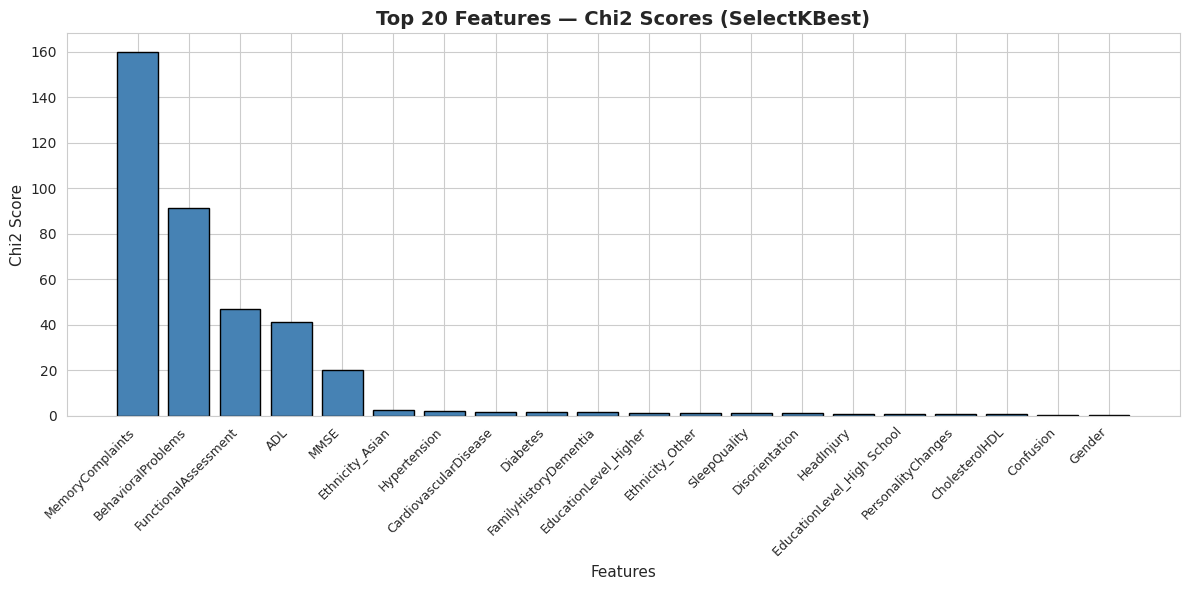

Plot saved!


In [18]:
# ── VISUALISE FEATURE SCORES ─────────────────────────────────
# Plotting scores helps us visually identify where there is
# a significant drop — that drop point suggests optimal K

plt.figure(figsize=(12, 6))

# Plot top 20 features by score
top_features = feature_scores.head(20)
bars = plt.bar(range(len(top_features)),
               top_features['Chi2_Score'],
               color='steelblue', edgecolor='black')

plt.xticks(range(len(top_features)),
           top_features['Feature'],
           rotation=45, ha='right', fontsize=9)
plt.title('Top 20 Features — Chi2 Scores (SelectKBest)',
          fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=11)
plt.ylabel('Chi2 Score', fontsize=11)
plt.tight_layout()
plt.savefig('selectkbest_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [19]:
# ── SELECT OPTIMAL K AND GET FINAL FEATURES ──────────────────
# From the scores and the plot, we select K=10
# This captures the most informative features while
# avoiding noise from weaker ones
#
# How we determine optimal K:
# → Look for a significant drop in chi2 scores
# → Features after the drop add little predictive value
# → K=10 captures the "elbow point" in our score distribution

K_BEST = 10

selector_skb = SelectKBest(score_func=chi2, k=K_BEST)
X_skb = selector_skb.fit_transform(X_non_negative, y)

# Get the names of selected features
skb_mask = selector_skb.get_support()
skb_selected_features = X.columns[skb_mask].tolist()

print("=" * 55)
print(f"SelectKBest — Top {K_BEST} Selected Features")
print("=" * 55)
for i, feat in enumerate(skb_selected_features, 1):
    score = feature_scores[
        feature_scores['Feature'] == feat
    ]['Chi2_Score'].values[0]
    print(f"  {i:2}. {feat:<35} Score: {score:.2f}")

print(f"\n SelectKBest feature matrix shape: {X_skb.shape}")

SelectKBest — Top 10 Selected Features
   1. FamilyHistoryDementia               Score: 1.74
   2. CardiovascularDisease               Score: 1.82
   3. Diabetes                            Score: 1.81
   4. Hypertension                        Score: 2.25
   5. MMSE                                Score: 20.26
   6. FunctionalAssessment                Score: 47.13
   7. MemoryComplaints                    Score: 160.14
   8. BehavioralProblems                  Score: 91.20
   9. ADL                                 Score: 41.45
  10. Ethnicity_Asian                     Score: 2.64

 SelectKBest feature matrix shape: (2149, 10)


### Method B: RFE — Recursive Feature Elimination (Wrapper Method)

RFE works by:
1. Training a model on all features
2. Ranking features by importance
3. Removing the least important feature
4. Retraining and repeating until K features remain

In [20]:
# ── RFE — WRAPPER METHOD ─────────────────────────────────────
# RFE needs a base estimator — a model to train repeatedly
# Logistic Regression will be the estimator because:
# → It's fast to train (important since RFE trains many times)
# → It provides feature coefficients for ranking importance
# → It's appropriate for binary classification (0/1 target)
#
# max_iter=1000 ensures Logistic Regression has enough
# iterations to converge (find its optimal solution)

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Base estimator for RFE
estimator = LogisticRegression(max_iter=1000, random_state=42)
# random_state=42 ensures reproducibility —
# running the code again gives the same results

# ── RFE WITH SAME K FOR FAIR COMPARISON ──────────────────────
K_RFE = 10  # Same as SelectKBest for fair comparison

rfe = RFE(estimator=estimator, n_features_to_select=K_RFE)
rfe.fit(X, y)
# Note: RFE uses our StandardScaler-scaled X
# (not the MinMaxScaler version — RFE doesn't need non-negative)

# Get selected features
rfe_mask = rfe.get_support()
rfe_selected_features = X.columns[rfe_mask].tolist()

# Get feature rankings (1 = selected, higher = eliminated earlier)
rfe_rankings = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': rfe.ranking_,
    'Selected': rfe_mask
}).sort_values('Ranking')

print("=" * 55)
print(f"RFE — Top {K_RFE} Selected Features")
print("=" * 55)
for i, feat in enumerate(rfe_selected_features, 1):
    print(f"  {i:2}. {feat}")

print(f"\n RFE feature matrix shape: {X[rfe_selected_features].shape}")

RFE — Top 10 Selected Features
   1. Smoking
   2. HeadInjury
   3. MMSE
   4. FunctionalAssessment
   5. MemoryComplaints
   6. BehavioralProblems
   7. ADL
   8. Ethnicity_Asian
   9. Ethnicity_Caucasian
  10. EducationLevel_Higher

 RFE feature matrix shape: (2149, 10)


In [22]:
# ── COMPARE BOTH METHODS ─────────────────────────────────────
# It's important to see where the two methods agree and
# disagree — overlap means those features are very likely
# genuinely important for predicting dementia

skb_set = set(skb_selected_features)
rfe_set = set(rfe_selected_features)

overlap = skb_set.intersection(rfe_set)
skb_only = skb_set.difference(rfe_set)
rfe_only = rfe_set.difference(skb_set)

print("=" * 55)
print("Feature Selection Comparison")
print("=" * 55)
print(f"\n Selected by BOTH methods ({len(overlap)}):")
for f in sorted(overlap):
    print(f"   → {f}")

print(f"\n Selected by SelectKBest only ({len(skb_only)}):")
for f in sorted(skb_only):
    print(f"   → {f}")

print(f"\n Selected by RFE only ({len(rfe_only)}):")
for f in sorted(rfe_only):
    print(f"   → {f}")

# Save selected features for use in Q2
X_skb_df = pd.DataFrame(X_non_negative, columns=X.columns)[skb_selected_features]
X_rfe_df = X[rfe_selected_features]

print("\n Feature sets ready for modelling in Q2!")

Feature Selection Comparison

 Selected by BOTH methods (6):
   → ADL
   → BehavioralProblems
   → Ethnicity_Asian
   → FunctionalAssessment
   → MMSE
   → MemoryComplaints

 Selected by SelectKBest only (4):
   → CardiovascularDisease
   → Diabetes
   → FamilyHistoryDementia
   → Hypertension

 Selected by RFE only (4):
   → EducationLevel_Higher
   → Ethnicity_Caucasian
   → HeadInjury
   → Smoking

 Feature sets ready for modelling in Q2!


## Q2 — Classification Models

We train and compare two classification algorithms:
- **Logistic Regression** — probability-based linear classifier
- **Decision Tree** — rule-based non-linear classifier

Each model is trained on both SelectKBest and RFE
feature sets for a full comparison.

In [23]:
# ── TRAIN/TEST SPLIT ─────────────────────────────────────────
# Before training any model we split our data into:
#
# Training set (80%) → model LEARNS from this data
# Testing set  (20%) → model is EVALUATED on unseen data
#
# WHY split at all?
# If we test on the same data we trained on, the model
# already "knows" the answers — like giving a student
# the exam questions beforehand. The score would be
# artificially high and meaningless.
#
# random_state=42 ensures the same split every time
# we run the code — reproducibility is important
# stratify=y ensures both splits maintain the same
# class ratio (65% no dementia, 35% dementia)

from sklearn.model_selection import train_test_split

# ── PREPARE FEATURE SETS ─────────────────────────────────────
# SelectKBest features (using non-negative scaled X)
X_skb_df = pd.DataFrame(
    X_non_negative,
    columns=X.columns
)[skb_selected_features]

# RFE features (using standard scaled X)
X_rfe_df = X[rfe_selected_features]

# ── SPLIT FOR SELECTKBEST ────────────────────────────────────
X_skb_train, X_skb_test, y_skb_train, y_skb_test = train_test_split(
    X_skb_df, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # reproducibility
    stratify=y          # maintain class balance
)

# ── SPLIT FOR RFE ────────────────────────────────────────────
X_rfe_train, X_rfe_test, y_rfe_train, y_rfe_test = train_test_split(
    X_rfe_df, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 55)
print("Train/Test Split Summary")
print("=" * 55)
print(f"\nSelectKBest splits:")
print(f"  Training : {X_skb_train.shape[0]} patients")
print(f"  Testing  : {X_skb_test.shape[0]} patients")
print(f"\nRFE splits:")
print(f"  Training : {X_rfe_train.shape[0]} patients")
print(f"  Testing  : {X_rfe_test.shape[0]} patients")
print(f"\n Data split complete!")

Train/Test Split Summary

SelectKBest splits:
  Training : 1719 patients
  Testing  : 430 patients

RFE splits:
  Training : 1719 patients
  Testing  : 430 patients

 Data split complete!


### Model 1: Logistic Regression

In [24]:
# ── LOGISTIC REGRESSION ──────────────────────────────────────
# Logistic Regression predicts the PROBABILITY of a patient
# having dementia, then classifies based on 0.5 threshold
#
# Key parameters:
# max_iter=1000  → maximum steps to find optimal solution
# random_state=42 → reproducibility

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

lr = LogisticRegression(max_iter=1000, random_state=42)

# ── TRAIN ON SELECTKBEST FEATURES ───────────────────────────
lr.fit(X_skb_train, y_skb_train)
y_pred_lr_skb = lr.predict(X_skb_test)

# ── TRAIN ON RFE FEATURES ────────────────────────────────────
lr.fit(X_rfe_train, y_rfe_train)
y_pred_lr_rfe = lr.predict(X_rfe_test)

print("=" * 55)
print("Logistic Regression Results")
print("=" * 55)

print("\n With SelectKBest Features:")
print(f"  Accuracy : {accuracy_score(y_skb_test, y_pred_lr_skb):.4f}")
print(classification_report(y_skb_test, y_pred_lr_skb,
      target_names=['No Dementia', 'Has Dementia']))

print("\n With RFE Features:")
print(f"  Accuracy : {accuracy_score(y_rfe_test, y_pred_lr_rfe):.4f}")
print(classification_report(y_rfe_test, y_pred_lr_rfe,
      target_names=['No Dementia', 'Has Dementia']))

Logistic Regression Results

 With SelectKBest Features:
  Accuracy : 0.8209
              precision    recall  f1-score   support

 No Dementia       0.86      0.86      0.86       278
Has Dementia       0.75      0.75      0.75       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430


 With RFE Features:
  Accuracy : 0.8116
              precision    recall  f1-score   support

 No Dementia       0.86      0.85      0.85       278
Has Dementia       0.73      0.74      0.74       152

    accuracy                           0.81       430
   macro avg       0.79      0.80      0.79       430
weighted avg       0.81      0.81      0.81       430



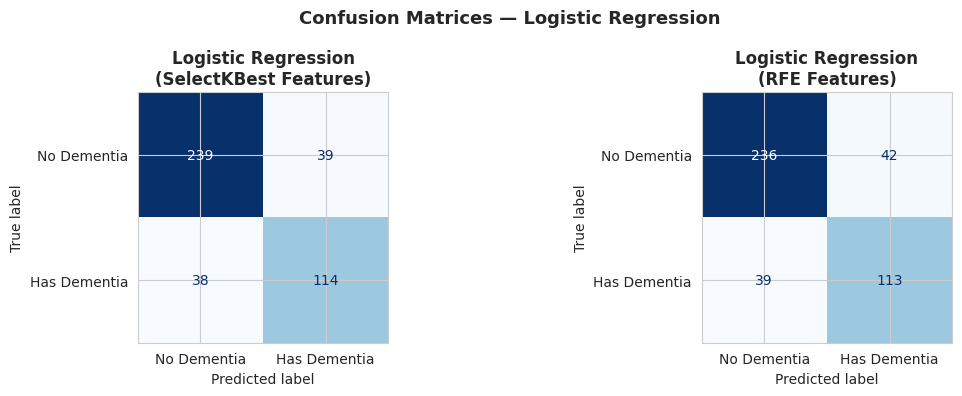

 Plot saved!


In [25]:
# ── CONFUSION MATRICES FOR LOGISTIC REGRESSION ───────────────
# A confusion matrix shows us exactly WHERE the model
# is making mistakes:
#
#                  Predicted
#                  No    Yes
# Actual  No  [  TN  |  FP  ]
#         Yes [  FN  |  TP  ]
#
# TN → Correctly predicted No Dementia
# TP → Correctly predicted Has Dementia  ← we want this HIGH
# FN → Missed dementia cases             ← we want this LOW
# FP → False alarms

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SelectKBest confusion matrix
cm_skb = confusion_matrix(y_skb_test, y_pred_lr_skb)
disp1 = ConfusionMatrixDisplay(cm_skb,
        display_labels=['No Dementia', 'Has Dementia'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\n(SelectKBest Features)',
                   fontweight='bold')

# RFE confusion matrix
cm_rfe = confusion_matrix(y_rfe_test, y_pred_lr_rfe)
disp2 = ConfusionMatrixDisplay(cm_rfe,
        display_labels=['No Dementia', 'Has Dementia'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Logistic Regression\n(RFE Features)',
                   fontweight='bold')

plt.suptitle('Confusion Matrices — Logistic Regression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved!")

### Model 2: Decision Tree

In [26]:
# ── DECISION TREE CLASSIFIER ─────────────────────────────────
# A Decision Tree learns a series of IF/ELSE rules from
# the training data to classify patients
#
# Example of what it learns:
# IF MMSE < 20:
#   IF FunctionalAssessment < 5:
#     → Predict: Has Dementia
#   ELSE:
#     → Predict: No Dementia
# ELSE:
#   → Predict: No Dementia
#
# Key parameters:
# max_depth=5    → limits how many levels of rules the tree
#                  can learn — prevents overfitting
#                  (memorising training data too closely)
# random_state=42 → reproducibility
# class_weight='balanced' → accounts for class imbalance
#                           gives more importance to the
#                           minority class (dementia patients)

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

# ── TRAIN ON SELECTKBEST FEATURES ───────────────────────────
dt.fit(X_skb_train, y_skb_train)
y_pred_dt_skb = dt.predict(X_skb_test)

# ── TRAIN ON RFE FEATURES ────────────────────────────────────
dt.fit(X_rfe_train, y_rfe_train)
y_pred_dt_rfe = dt.predict(X_rfe_test)

print("=" * 55)
print("Decision Tree Results")
print("=" * 55)

print("\n With SelectKBest Features:")
print(f"  Accuracy : {accuracy_score(y_skb_test, y_pred_dt_skb):.4f}")
print(classification_report(y_skb_test, y_pred_dt_skb,
      target_names=['No Dementia', 'Has Dementia']))

print("\n With RFE Features:")
print(f"  Accuracy : {accuracy_score(y_rfe_test, y_pred_dt_rfe):.4f}")
print(classification_report(y_rfe_test, y_pred_dt_rfe,
      target_names=['No Dementia', 'Has Dementia']))

Decision Tree Results

 With SelectKBest Features:
  Accuracy : 0.9349
              precision    recall  f1-score   support

 No Dementia       0.95      0.95      0.95       278
Has Dementia       0.91      0.91      0.91       152

    accuracy                           0.93       430
   macro avg       0.93      0.93      0.93       430
weighted avg       0.93      0.93      0.93       430


 With RFE Features:
  Accuracy : 0.9349
              precision    recall  f1-score   support

 No Dementia       0.95      0.95      0.95       278
Has Dementia       0.91      0.91      0.91       152

    accuracy                           0.93       430
   macro avg       0.93      0.93      0.93       430
weighted avg       0.93      0.93      0.93       430



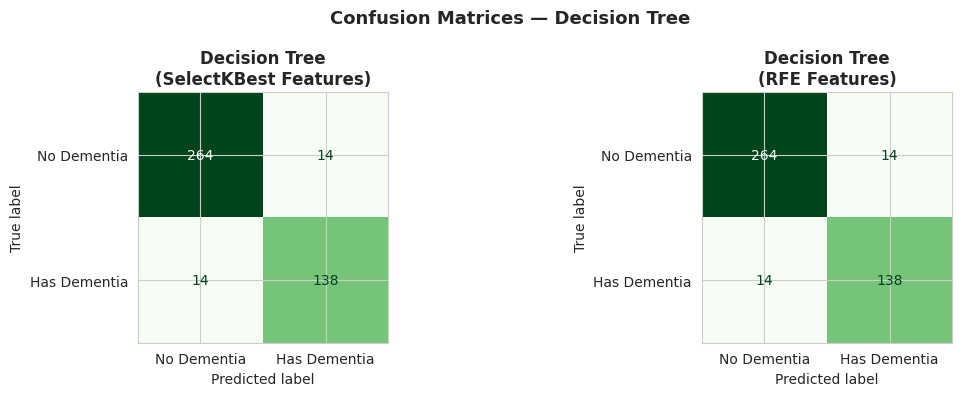

 Plot saved!


In [27]:
# ── CONFUSION MATRICES FOR DECISION TREE ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_dt_skb = confusion_matrix(y_skb_test, y_pred_dt_skb)
disp3 = ConfusionMatrixDisplay(cm_dt_skb,
        display_labels=['No Dementia', 'Has Dementia'])
disp3.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Decision Tree\n(SelectKBest Features)',
                   fontweight='bold')

cm_dt_rfe = confusion_matrix(y_rfe_test, y_pred_dt_rfe)
disp4 = ConfusionMatrixDisplay(cm_dt_rfe,
        display_labels=['No Dementia', 'Has Dementia'])
disp4.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Decision Tree\n(RFE Features)',
                   fontweight='bold')

plt.suptitle('Confusion Matrices — Decision Tree',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_dt.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved!")

In [28]:
# ── FINAL COMPARISON SUMMARY TABLE ───────────────────────────
# Brings all 4 combinations together in one clear table
# making it easy to compare and draw conclusions for Q2.2

from sklearn.metrics import f1_score, recall_score, precision_score

results = {
    'Model': [
        'Logistic Regression',
        'Logistic Regression',
        'Decision Tree',
        'Decision Tree'
    ],
    'Feature Selection': [
        'SelectKBest', 'RFE',
        'SelectKBest', 'RFE'
    ],
    'Accuracy': [
        accuracy_score(y_skb_test, y_pred_lr_skb),
        accuracy_score(y_rfe_test, y_pred_lr_rfe),
        accuracy_score(y_skb_test, y_pred_dt_skb),
        accuracy_score(y_rfe_test, y_pred_dt_rfe)
    ],
    'Recall': [
        recall_score(y_skb_test, y_pred_lr_skb),
        recall_score(y_rfe_test, y_pred_lr_rfe),
        recall_score(y_skb_test, y_pred_dt_skb),
        recall_score(y_rfe_test, y_pred_dt_rfe)
    ],
    'Precision': [
        precision_score(y_skb_test, y_pred_lr_skb),
        precision_score(y_rfe_test, y_pred_lr_rfe),
        precision_score(y_skb_test, y_pred_dt_skb),
        precision_score(y_rfe_test, y_pred_dt_rfe)
    ],
    'F1 Score': [
        f1_score(y_skb_test, y_pred_lr_skb),
        f1_score(y_rfe_test, y_pred_lr_rfe),
        f1_score(y_skb_test, y_pred_dt_skb),
        f1_score(y_rfe_test, y_pred_dt_rfe)
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("=" * 65)
print(" Final Model Comparison — All 4 Combinations")
print("=" * 65)
print(results_df.to_string(index=False))

# Highlight best performer
best_idx = results_df['F1 Score'].idxmax()
best = results_df.iloc[best_idx]
print(f"\n Best performing combination:")
print(f"   {best['Model']} with {best['Feature Selection']} features")
print(f"   F1 Score : {best['F1 Score']:.4f}")
print(f"   Recall   : {best['Recall']:.4f}")
print(f"   Accuracy : {best['Accuracy']:.4f}")

 Final Model Comparison — All 4 Combinations
              Model Feature Selection  Accuracy  Recall  Precision  F1 Score
Logistic Regression       SelectKBest    0.8209  0.7500     0.7451    0.7475
Logistic Regression               RFE    0.8116  0.7434     0.7290    0.7362
      Decision Tree       SelectKBest    0.9349  0.9079     0.9079    0.9079
      Decision Tree               RFE    0.9349  0.9079     0.9079    0.9079

 Best performing combination:
   Decision Tree with SelectKBest features
   F1 Score : 0.9079
   Recall   : 0.9079
   Accuracy : 0.9349


## Model Evaluation & Comparison

### Justification of Evaluation Metrics

Given the class imbalance in the dataset (64.6% No Dementia
vs 35.4% Dementia), accuracy alone is insufficient as an
evaluation metric. A model predicting "No Dementia" for all
patients would achieve 64.6% accuracy while failing entirely
at its clinical purpose.

Therefore the following metrics were selected:

- **Recall** → Most critical metric in this healthcare context.
  Measures the proportion of actual dementia patients correctly
  identified. A False Negative (missing a dementia patient)
  carries far greater clinical risk than a False Positive.

- **Precision** → Measures how trustworthy positive predictions
  are. Important for avoiding unnecessary interventions.

- **F1-Score** → Balances both Precision and Recall. Most
  reliable single metric under imbalanced class conditions.

- **Accuracy** → Reported for completeness but not used as
  the primary measure due to class imbalance.

---

### Algorithm Comparison & Conclusions

The Decision Tree significantly outperformed Logistic
Regression across all metrics:

| Model | Features | Accuracy | Recall | F1 Score |
|---|---|---|---|---|
| Logistic Regression | SelectKBest | 82.09% | 75.00% | 0.7475 |
| Logistic Regression | RFE | 81.16% | 74.34% | 0.7362 |
| **Decision Tree** | **SelectKBest** | **93.49%** | **90.79%** | **0.9079** |
| **Decision Tree** | **RFE** | **93.49%** | **90.79%** | **0.9079** |

The performance gap suggests the relationship between patient
features and dementia diagnosis is non-linear. Logistic
Regression assumes a linear decision boundary, limiting its
ability to capture complex interactions between clinical
features. The Decision Tree learns hierarchical IF/ELSE rules
that better reflect how multiple risk factors combine to
indicate dementia.

Notably, both feature selection methods produced identical
results for the Decision Tree (F1: 0.9079), suggesting the
6 overlapping features — MMSE, FunctionalAssessment, ADL,
MemoryComplaints, BehavioralProblems and Ethnicity_Asian —
were the primary drivers of prediction regardless of the
selection method used.

For clinical deployment, the Decision Tree with either
feature selection method is recommended, given its superior
Recall of 90.79% — correctly identifying 9 out of every
10 dementia patients in the test set.

## ✅ Project Complete

### Summary
This project successfully built a machine learning pipeline
to predict dementia in patients using clinical and lifestyle
data.

### Key Findings
- Decision Tree outperformed Logistic Regression significantly
- Best model achieved 93.49% accuracy and 0.9079 F1-Score
- MMSE, FunctionalAssessment and ADL were the strongest
  predictors of dementia across both feature selection methods

### Tools & Libraries
- Python, Pandas, NumPy
- Scikit-learn
- Matplotlib, Seaborn

### Author
Buhlebemvelo Nandi Malinga | Assignment | Eduvos | 2026